# 0. ENVIRONMENT SETUP & OPTIMIZATIONS

In [23]:
# TensorFlow environment initialization, GPU optimization, mixed precision, and library imports.

import tensorflow as tf
from tensorflow.keras import mixed_precision
import numpy as np
import pandas as pd
import json
import os
import zipfile
import datetime
import shutil
import tensorboard
from difflib import get_close_matches
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs Available:", gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.optimizer.set_jit(True)
        print(" XLA JIT enabled.")
    except RuntimeError as e:
        print(e)

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Compute dtype:", policy.compute_dtype)
print("Variable dtype:", policy.variable_dtype)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorBoard version:", tensorboard.__version__)

TensorFlow version: 2.19.0
GPUs Available: []
Compute dtype: float16
Variable dtype: float32
TensorBoard version: 2.19.0


# 1. Extract Processed Dataset

In [24]:
PROCESSED_INPUT_DIR = "/kaggle/input/datasets/gilangagung/qlop-intelligent-learning-recommendation-dataset"
PROCESSED_DIR = "/kaggle/working/processed"

if os.path.exists(PROCESSED_INPUT_DIR):
    if os.path.exists(PROCESSED_DIR):
        shutil.rmtree(PROCESSED_DIR)
        
    shutil.copytree(PROCESSED_INPUT_DIR, PROCESSED_DIR)
    print("Processed data copied to working directory.")
    print("Files:", os.listdir(PROCESSED_DIR))
else:
    print(f"Error: Folder {PROCESSED_INPUT_DIR} not found.")
    
print("Processed data Copied.")
print("Files:", os.listdir(PROCESSED_DIR))


Processed data copied to working directory.
Files: ['cat_embeddings.npz', 'skill_vocab_linkedin.json', 'role_embeddings.npz', 'role_freq.json', 'coursera_cleaned.csv', 'unique_skills_raw.txt', 'synthetic_users_skill_priority_scorer.npz', 'train_test_split_info.json', 'linkedin_to_coursera_mapping.json', 'synthetic_demand_course_two_tower.npz', 'skill_vocab_coursera.json']
Processed data Copied.
Files: ['cat_embeddings.npz', 'skill_vocab_linkedin.json', 'role_embeddings.npz', 'role_freq.json', 'coursera_cleaned.csv', 'unique_skills_raw.txt', 'synthetic_users_skill_priority_scorer.npz', 'train_test_split_info.json', 'linkedin_to_coursera_mapping.json', 'synthetic_demand_course_two_tower.npz', 'skill_vocab_coursera.json']


# 2. Load Vocabulary And Data Synthetis

In [25]:
# Loading vocabularies, mappings, synthetic user data, and training-validation splits.

vocab_li_path = os.path.join(PROCESSED_DIR, "skill_vocab_linkedin.json")
with open(vocab_li_path, 'r') as f:
    vocab_li = json.load(f)
skill_to_idx_li = vocab_li["skill_to_idx"]
idx_to_skill_li = vocab_li["idx_to_skill"]
N_SKILLS_LI = vocab_li["vocab_size"]
print(f"Vocabulary LinkedIn size: {N_SKILLS_LI}")

vocab_cr_path = os.path.join(PROCESSED_DIR, "skill_vocab_coursera.json")
with open(vocab_cr_path, 'r') as f:
    vocab_cr = json.load(f)
skill_to_idx_cr = vocab_cr["skill_to_idx"]
idx_to_skill_cr = vocab_cr["idx_to_skill"]
N_SKILLS_CR = vocab_cr["vocab_size"]
print(f"Vocabulary Coursera size: {N_SKILLS_CR}")

mapping_path = os.path.join(PROCESSED_DIR, "linkedin_to_coursera_mapping.json")
with open(mapping_path, 'r') as f:
    linkedin_to_coursera = json.load(f)
print(f"Mapping loaded, entries: {len(linkedin_to_coursera)}")

users_npz = np.load(os.path.join(PROCESSED_DIR, "synthetic_users_skill_priority_scorer.npz"))
X_users = users_npz["X_users"]
X_roles_idx = users_npz["X_roles"]
Y_targets = users_npz["Y_targets"]
role_list = users_npz["role_list"]
N_ROLES = len(role_list)
role_to_idx = {role: i for i, role in enumerate(role_list)}
idx_to_role = {i: role for role, i in role_to_idx.items()}
print(f"Users: {X_users.shape}, Roles: {N_ROLES}")

demand_npz = np.load(os.path.join(PROCESSED_DIR, "synthetic_demand_course_two_tower.npz"))
demand_vectors = demand_npz["demand_vectors"]
course_vectors_all = demand_npz["course_vectors"]
course_indices = demand_npz["course_indices"]
targets_demand = demand_npz["targets"]
course_names = demand_npz["course_names"]
course_urls = demand_npz["course_urls"]
num_courses = len(course_names)
print(f"Demand: {demand_vectors.shape}, Courses: {num_courses}")

coursera_csv = os.path.join(PROCESSED_DIR, "coursera_cleaned.csv")
df_coursera = pd.read_csv(coursera_csv)
print(f"Coursera dataframe loaded: {df_coursera.shape}")

split_path = os.path.join(PROCESSED_DIR, "train_test_split_info.json")
with open(split_path, 'r') as f:
    split_info = json.load(f)
train_idx_u = split_info["skill_priority_scorer"]["train_indices"]
val_idx_u   = split_info["skill_priority_scorer"]["val_indices"]
train_idx_d = split_info["two_tower_course"]["train_indices"]
val_idx_d   = split_info["two_tower_course"]["val_indices"]
test_idx_u = split_info["skill_priority_scorer"]["test_indices"]
test_idx_d = split_info["two_tower_course"]["test_indices"]

Vocabulary LinkedIn size: 489
Vocabulary Coursera size: 1999
Mapping loaded, entries: 489
Users: (20000, 489), Roles: 27
Demand: (15000, 489), Courses: 1980
Coursera dataframe loaded: (1980, 27)


# 3. Custom Loss, Callback, & Layers

In [26]:
class WeightedMAE(tf.keras.losses.Loss):
    def __init__(self, alpha=2.0, name="weighted_mae"):
        super().__init__(name=name)
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        weights = 1.0 + self.alpha * y_true
        absolute_error = tf.abs(y_true - y_pred)
        weighted_error = weights * absolute_error
        return tf.reduce_mean(weighted_error)

class EarlyStoppingOnTargetMAE(tf.keras.callbacks.Callback):
    def __init__(self, target_mae=0.02, save_path="./best_model"):
        super().__init__()
        self.target_mae = target_mae
        self.save_path = save_path
        self.best_mae = np.inf
        self.stopped = False

    def on_epoch_end(self, epoch, logs=None):
        current_mae = logs.get("val_mae")
        if current_mae is not None:
            if current_mae < self.best_mae:
                self.best_mae = current_mae
                self.model.export(self.save_path)
                print(f"\nModel improved at epoch {epoch+1} (MAE: {current_mae:.4f}). Saved.")
            if current_mae <= self.target_mae:
                print(f"\nTarget MAE {self.target_mae} reached at epoch {epoch+1}. Stopping training.")
                self.stopped = True

class InteractionLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim=32):
        super(InteractionLayer, self).__init__()
        self.embed_dim = embed_dim
        self.w = self.add_weight(
            shape=(embed_dim, embed_dim),
            initializer='random_normal',
            trainable=True,
            name='interaction_weight',
            dtype=tf.float32
        )

    def call(self, demand_emb, course_emb):
        demand_emb = tf.cast(demand_emb, tf.float32)
        course_emb = tf.cast(course_emb, tf.float32)
        w_float32 = tf.cast(self.w, tf.float32)
        demand_transformed = tf.matmul(demand_emb, w_float32)
        interaction = tf.reduce_sum(demand_transformed * course_emb, axis=1, keepdims=True)
        return interaction

print("Custom components defined.")

Custom components defined.


# 4. SKILL PRIORITY SCORER (Model 3) Build & Train dengan Optimasi Pipeline

In [27]:
# Model building, data pipelining, training loop, and training visualizations for SkillPriorityScorer.

def build_model3(N_SKILLS_LI, N_ROLES, embedding_dim=8):
    input_skills = tf.keras.layers.Input(shape=(N_SKILLS_LI,), dtype=tf.float32, name="user_skills")
    input_role = tf.keras.layers.Input(shape=(1,), dtype=tf.int32, name="role_index")
    role_emb = tf.keras.layers.Embedding(input_dim=N_ROLES, output_dim=embedding_dim, name="role_embedding")(input_role)
    role_emb = tf.keras.layers.Flatten()(role_emb)
    concat = tf.keras.layers.Concatenate()([input_skills, role_emb])
    x = tf.keras.layers.Dense(128, activation='relu', name="dense1")(concat)
    x = tf.keras.layers.Dropout(0.3, name="dropout1")(x)
    x = tf.keras.layers.Dense(64, activation='relu', name="dense2")(x)
    output = tf.keras.layers.Dense(N_SKILLS_LI, activation='sigmoid', dtype=tf.float32, name="output")(x)
    return tf.keras.Model(inputs=[input_skills, input_role], outputs=output, name="SkillPriorityScorer")

model3 = build_model3(N_SKILLS_LI, N_ROLES)
model3.summary()

BATCH_SIZE = 64
X_train_skills = X_users[train_idx_u]
X_train_roles = X_roles_idx[train_idx_u].reshape(-1, 1)
y_train = Y_targets[train_idx_u]
X_val_skills = X_users[val_idx_u]
X_val_roles = X_roles_idx[val_idx_u].reshape(-1, 1)
y_val = Y_targets[val_idx_u]

train_ds = tf.data.Dataset.from_tensor_slices(((X_train_skills, X_train_roles), y_train))
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(((X_val_skills, X_val_roles), y_val))
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

loss_fn = WeightedMAE(alpha=2.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

train_loss = tf.keras.metrics.Mean(name='train_loss')
train_mae = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
train_acc = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='train_acc')
val_loss = tf.keras.metrics.Mean(name='val_loss')
val_mae = tf.keras.metrics.MeanAbsoluteError(name='val_mae')
val_acc = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='val_acc')

log_dir = "/kaggle/working/logs/skill_priority_scorer/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = tf.summary.create_file_writer(log_dir)

os.makedirs("/kaggle/working/models/skill_priority_scorer_savedmodel", exist_ok=True)
early_stop3 = EarlyStoppingOnTargetMAE(target_mae=0.02, save_path="/kaggle/working/models/skill_priority_scorer_savedmodel")

@tf.function
def train_step3(x, y):
    with tf.GradientTape() as tape:
        predictions = model3(x, training=True)
        loss = loss_fn(y, predictions)
    gradients = tape.gradient(loss, model3.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model3.trainable_variables))
    train_loss.update_state(loss)
    train_mae.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    train_acc.update_state(y_bin, pred_bin)

def val_step3(x, y):
    predictions = model3(x, training=False)
    loss = loss_fn(y, predictions)
    val_loss.update_state(loss)
    val_mae.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    val_acc.update_state(y_bin, pred_bin)

history = {'loss':[], 'mae':[], 'acc':[], 'val_loss':[], 'val_mae':[], 'val_acc':[]}

EPOCHS = 30
print("Start training Skill Priority Scorer Model...")
for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_mae.reset_state()
    train_acc.reset_state()
    val_loss.reset_state()
    val_mae.reset_state()
    val_acc.reset_state()
    
    for step, (x_batch, y_batch) in enumerate(train_ds):
        train_step3(x_batch, y_batch)
    for x_val_batch, y_val_batch in val_ds:
        val_step3(x_val_batch, y_val_batch)
    
    t_l = train_loss.result().numpy()
    t_m = train_mae.result().numpy()
    t_a = train_acc.result().numpy()
    v_l = val_loss.result().numpy()
    v_m = val_mae.result().numpy()
    v_a = val_acc.result().numpy()
    
    history['loss'].append(t_l)
    history['mae'].append(t_m)
    history['acc'].append(t_a)
    history['val_loss'].append(v_l)
    history['val_mae'].append(v_m)
    history['val_acc'].append(v_a)
    
    with summary_writer.as_default():
        tf.summary.scalar('loss/train', t_l, step=epoch)
        tf.summary.scalar('mae/train', t_m, step=epoch)
        tf.summary.scalar('accuracy/train', t_a, step=epoch)
        tf.summary.scalar('loss/val', v_l, step=epoch)
        tf.summary.scalar('mae/val', v_m, step=epoch)
        tf.summary.scalar('accuracy/val', v_a, step=epoch)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {t_l:.4f} MAE: {t_m:.4f} Acc: {t_a:.4f} | Val Loss: {v_l:.4f} MAE: {v_m:.4f} Acc: {v_a:.4f}")
    
    early_stop3.set_model(model3)
    early_stop3.on_epoch_end(epoch, {"val_mae": v_m, "val_loss": v_l})
    if early_stop3.stopped:
        print("Training stopped by callback.")
        break

model3.export("/kaggle/working/models/skill_priority_scorer_savedmodel")
print("Skill Priority Scorer model final saved.")


Model: "SkillPriorityScorer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ role_index          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ role_embedding      │ (None, 1, 8)      │        216 │ role_index[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_skills         │ (None, 489)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ role_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 497)       │          0 │ user_skills[0][0… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 128)       │     63,744 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 128)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 64)        │      8,256 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 489)       │     31,785 │ dense2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,001 (406.25 KB)

 Trainable params: 104,001 (406.25 KB)

 Non-trainable params: 0 (0.00 B)

...

Saved artifact at '/kaggle/working/models/skill_priority_scorer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float32, name='user_skills'), TensorSpec(shape=(None, 1), dtype=tf.int32, name='role_index')]
Output Type:
  TensorSpec(shape=(None, 489), dtype=tf.float32, name=None)
Captures:
  132141382512528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382509264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382508880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382513104: TensorSpec(shape=(), dtype=tf.resource, name=None)

Model improved at epoch 23 (MAE: 0.0201). Saved.
Epoch 24/30 | Train Loss: 0.0352 MAE: 0.0217 Acc: 0.9859 | Val Loss: 0.032

INFO:tensorflow:Assets written to: /kaggle/working/models/skill_priority_scorer_savedmodel/assets


Saved artifact at '/kaggle/working/models/skill_priority_scorer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float32, name='user_skills'), TensorSpec(shape=(None, 1), dtype=tf.int32, name='role_index')]
Output Type:
  TensorSpec(shape=(None, 489), dtype=tf.float32, name=None)
Captures:
  132141382512528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382509264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382508880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382513104: TensorSpec(shape=(), dtype=tf.resource, name=None)

Model improved at epoch 24 (MAE: 0.0199). Saved.

Target MAE 0.02 reached at epoch 24. Stopping training.
Training stopped 

INFO:tensorflow:Assets written to: /kaggle/working/models/skill_priority_scorer_savedmodel/assets


Saved artifact at '/kaggle/working/models/skill_priority_scorer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float32, name='user_skills'), TensorSpec(shape=(None, 1), dtype=tf.int32, name='role_index')]
Output Type:
  TensorSpec(shape=(None, 489), dtype=tf.float32, name=None)
Captures:
  132141382512528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382509264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382508880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382506000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141382513104: TensorSpec(shape=(), dtype=tf.resource, name=None)
Skill Priority Scorer model final saved.


In [28]:
# Mass test skill priority scorer across 27 roles.


role_user_skills = {
    "Software Engineer": ["react.js", "python", "javascript", "typescript", "next.js", "kubernetes"],
    "Backend Developer": ["python", "go", "docker", "postgresql", "nodejs", "kubernetes"],
    "Frontend Developer": ["react.js", "javascript", "typescript", "css", "next.js", "html"],
    "Full Stack Developer": ["react.js", "javascript", "nodejs", "typescript", "python", "docker"],
    "Mobile Developer": ["kotlin", "git", "swift", "c", "react native"],
    "General IT Specialist": ["python", "next.js", "go", "linux", "r", "kubernetes"],
    "QA Engineer": ["python", "selenium", "next.js", "postman", "javascript"],
    "Security Engineer": ["python", "linux", "kubernetes", "bash", "nmap"],
    "AI Engineer": ["python", "pytorch", "tensorflow", "kubernetes", "docker"],
    "DevOps Engineer": ["kubernetes", "docker", "python", "linux", "bash", "github"],
    "Business Intelligence Analyst": ["python", "tableau", "r", "bigquery", "snowflake"],
    "Data Engineer": ["python", "snowflake", "bigquery", "scala", "nosql", "docker"],
    "Data Scientist": ["python", "r", "tensorflow", "pytorch", "scikit-learn"],
    "Data Analyst": ["python", "tableau", "r", "snowflake", "excel"],
    "Machine Learning Engineer": ["python", "pytorch", "tensorflow", "mlflow", "kubernetes"],
    "Solutions Architect": ["python", "kubernetes", "docker", "nodejs", "react.js"],
    "Site Reliability Engineer": ["python", "kubernetes", "linux", "docker", "bash", "go"],
    "Cloud Engineer": ["kubernetes", "python", "linux", "docker", "bash"],
    "Product Manager": ["go", "next.js", "python", "tableau"],
    "IT Consultant": ["python", "go", "javascript", "c#", "docker"],
    "Network Engineer": ["python", "linux", "vmware", "wireshark", "bash"],
    "Embedded/IoT Engineer": ["c", "c++", "python", "linux", "git"],
    "Database Administrator": ["postgresql", "linux", "mysql", "python", "mongodb"],
    "Cyber Security Analyst": ["python", "linux", "bash", "nmap", "metasploit"],
    "Business Analyst": ["python", "tableau", "go", "snowflake", "excel"],
    "Robotics Engineer": ["python", "javascript", "selenium", "git", "docker"],
    "ERP Consultant": ["next.js", "c", "go", "python", "microsoft dynamics"]
}

def fuzzy_match_skill(skill, vocab_keys, threshold=0.7):
    matches = get_close_matches(skill, vocab_keys, n=1, cutoff=threshold)
    return matches[0] if matches else None

loaded3 = tf.saved_model.load("/kaggle/working/models/skill_priority_scorer_savedmodel")
infer3 = loaded3.signatures['serving_default']
print("Skill Priority Scorer loaded for mass testing.\n")

for role, raw_skills in role_user_skills.items():
    print(f"{'='*60}")
    print(f"Role: {role}")
    print(f"User skills (raw): {raw_skills}")

    cv_skills = [s.lower().strip() for s in raw_skills if s.strip()]
    user_vec = np.zeros((1, N_SKILLS_LI), dtype=np.float32)
    vocab_keys = list(skill_to_idx_li.keys())
    recognized = []
    for s in cv_skills:
        if s in skill_to_idx_li:
            user_vec[0, skill_to_idx_li[s]] = 1.0
            recognized.append(s)
        else:
            best = fuzzy_match_skill(s, vocab_keys, threshold=0.7)
            if best:
                user_vec[0, skill_to_idx_li[best]] = 1.0
                recognized.append(best)
    print(f"Recognized skills: {recognized}")

    role_idx = np.array([[role_to_idx[role]]], dtype=np.int32)
    out3 = infer3(user_skills=tf.constant(user_vec), role_index=tf.constant(role_idx))
    pred_scores = out3['output_0'].numpy()[0]

    mask = user_vec[0] == 0
    pred_scores_masked = np.where(mask, pred_scores, -1.0)

    top_indices = np.argsort(pred_scores_masked)[::-1][:15]
    print("Top 15 missing skills (priority):")
    for i, idx in enumerate(top_indices, 1):
        score = pred_scores_masked[idx]
        if score > 0:
            skill_name = idx_to_skill_li[str(idx)]
            print(f"  {i:2d}. {skill_name:<30s} {score:.4f}")
    print()

Skill Priority Scorer loaded for mass testing.

Role: Software Engineer
User skills (raw): ['react.js', 'python', 'javascript', 'typescript', 'next.js', 'kubernetes']
Recognized skills: ['react.js', 'python', 'javascript', 'typescript', 'next.js', 'kubernetes']
Top 15 missing skills (priority):
   1. vue                            0.8569
   2. css                            0.8357
   3. kotlin                         0.8116
   4. spring boot                    0.7787
   5. graphql                        0.6975
   6. react native                   0.6959
   7. webpack                        0.6529
   8. nosql                          0.6363
   9. microservices architecture     0.6118
  10. .net                           0.6091
  11. jquery                         0.5911
  12. jest                           0.5869
  13. component libraries            0.5857
  14. django                         0.5837
  15. redis                          0.5784

Role: Backend Developer
User skills (raw): 

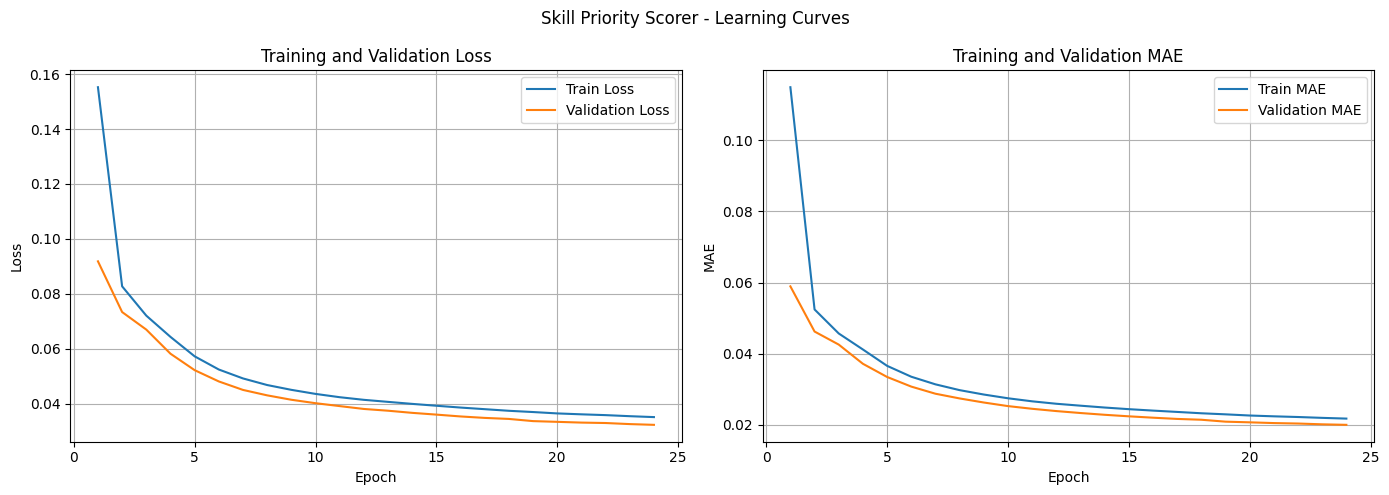

Fig 1: Learning curves (loss & MAE) indicate convergence and potential overfitting.


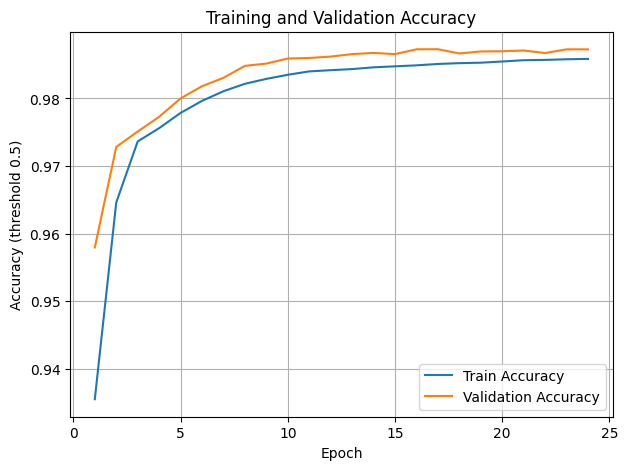

Fig 2: Accuracy curves show classification performance at threshold 0.5.


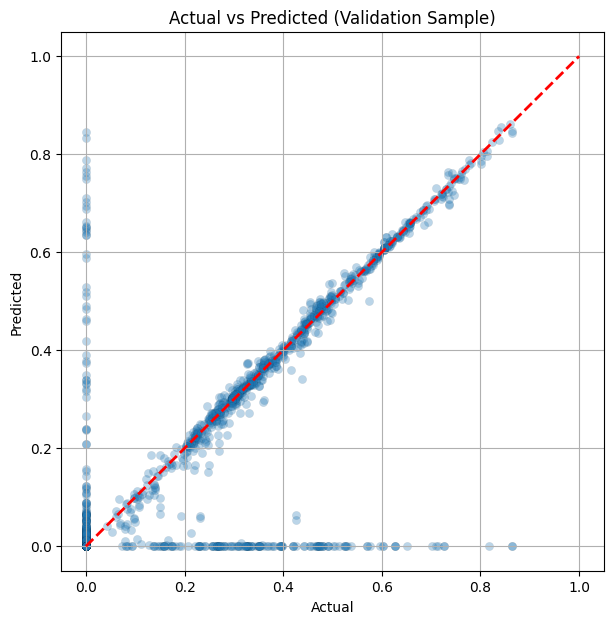

Fig 3: Scatter of actual vs predicted. Ideal points lie on the red diagonal.


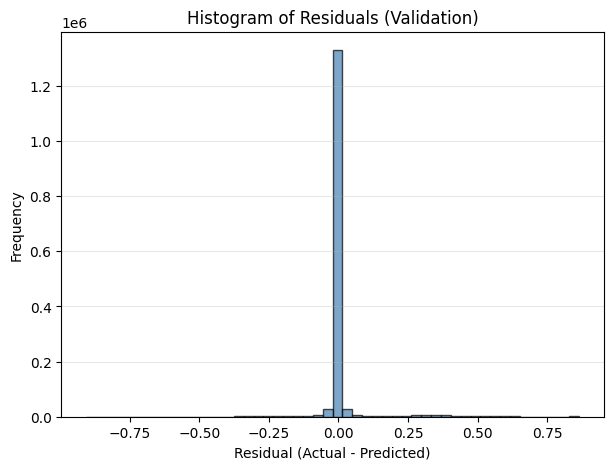

Fig 4: Residual distribution should be centered near zero.


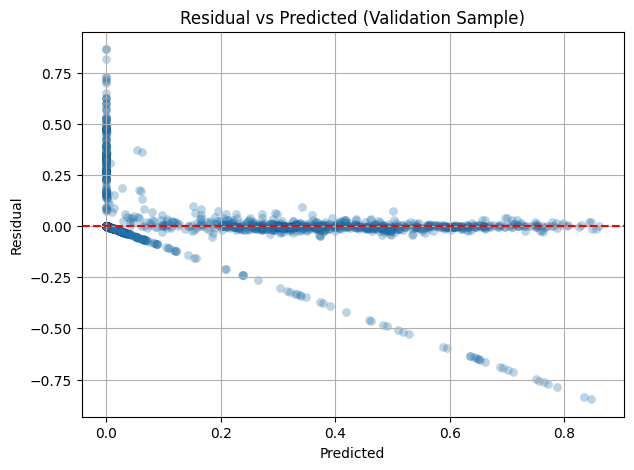

Fig 5: Residual vs predicted reveals heteroscedasticity or bias.


In [29]:

epochs_range = range(1, len(history['loss'])+1)

# 1. Loss and MAE curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, history['loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history['mae'], label='Train MAE')
ax2.plot(epochs_range, history['val_mae'], label='Validation MAE')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)
plt.suptitle('Skill Priority Scorer - Learning Curves')
plt.tight_layout()
plt.show()
print("Fig 1: Learning curves (loss & MAE) indicate convergence and potential overfitting.")

# 2. Accuracy curves
plt.figure(figsize=(7,5))
plt.plot(epochs_range, history['acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (threshold 0.5)')
plt.legend()
plt.grid(True)
plt.show()
print("Fig 2: Accuracy curves show classification performance at threshold 0.5.")

# 3. Scatter plot actual vs predicted (on validation set)
val_preds = model3.predict(val_ds, verbose=0)
y_val_flat = y_val.flatten()
preds_flat = val_preds.flatten()
# subsample for clarity
indices = np.random.choice(len(y_val_flat), size=min(5000, len(y_val_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_val_flat[indices], preds_flat[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 3: Scatter of actual vs predicted. Ideal points lie on the red diagonal.")

# 4. Histogram of residuals (validation)
residuals = y_val_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Validation)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Residual distribution should be centered near zero.")

# 5. Residual vs Predicted (validation)
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[indices], residuals[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 5: Residual vs predicted reveals heteroscedasticity or bias.")

Test MAE: 0.0200, Test MSE: 0.0079, Test Accuracy (threshold 0.5): 0.9875


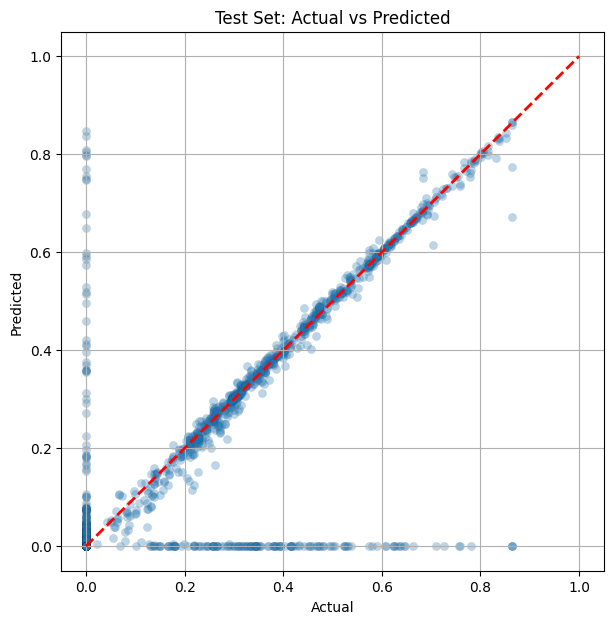

Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.


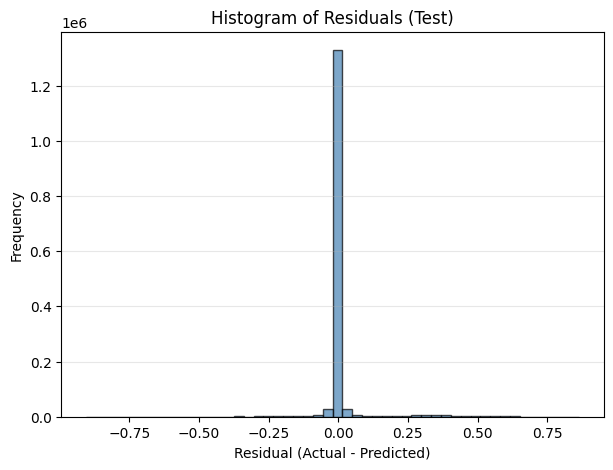

Fig 2: Residual distribution centered near zero shows unbiased predictions.


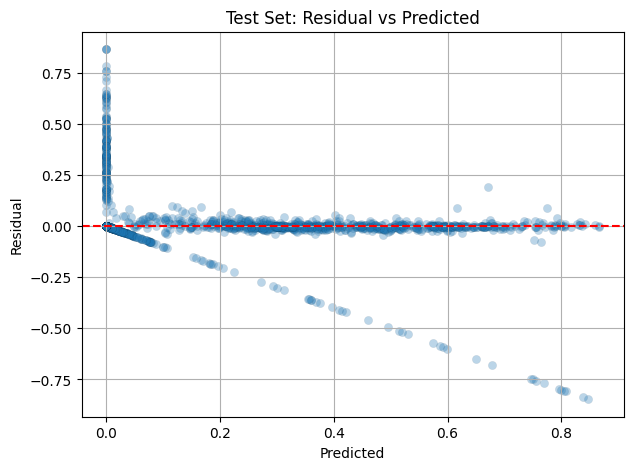

Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.


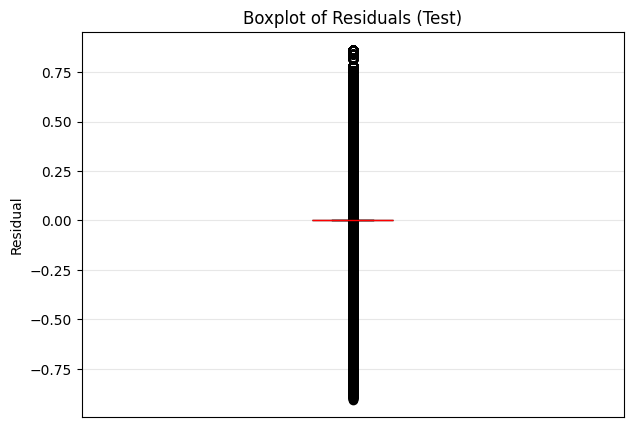

Fig 4: Boxplot shows the spread and symmetry of residuals.


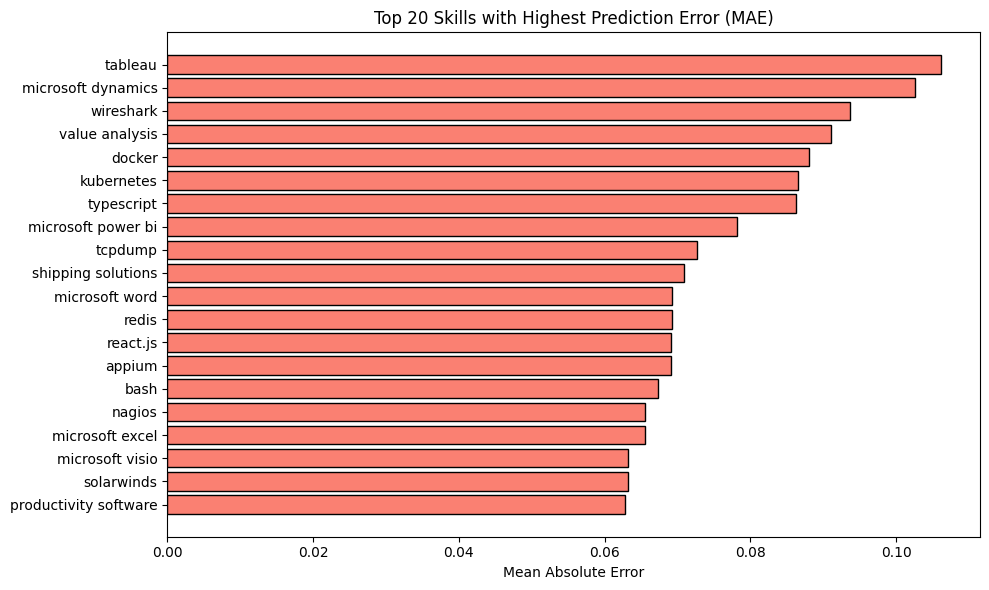

Fig 5: Skills with high MAE might be under-represented or have ambiguous patterns.


In [30]:
# Skill Priority Scorer Testing: load best model, evaluate on test set, compute metrics, and plot 5 diagnostic visualizations.


# Load best saved model
best_model3 = tf.saved_model.load("/kaggle/working/models/skill_priority_scorer_savedmodel")
infer_best3 = best_model3.signatures['serving_default']

# Prepare test data
X_test_skills = X_users[test_idx_u]
X_test_roles = X_roles_idx[test_idx_u].reshape(-1, 1)
y_test = Y_targets[test_idx_u]

# Predict function (batch to avoid OOM)
def predict_skill_priority(model, skills, roles, batch_size=256):
    preds = []
    for i in range(0, len(skills), batch_size):
        batch_skills = tf.constant(skills[i:i+batch_size], dtype=tf.float32)
        batch_roles = tf.constant(roles[i:i+batch_size], dtype=tf.int32)
        out = model(user_skills=batch_skills, role_index=batch_roles)
        preds.append(out['output_0'].numpy())
    return np.concatenate(preds, axis=0)

test_preds = predict_skill_priority(infer_best3, X_test_skills, X_test_roles)

# Flatten for metrics
y_test_flat = y_test.flatten()
preds_flat = test_preds.flatten()

# Compute metrics
mae_test = np.mean(np.abs(y_test_flat - preds_flat))
mse_test = np.mean((y_test_flat - preds_flat)**2)
acc_test = np.mean((y_test_flat > 0.5) == (preds_flat > 0.5))
print(f"Test MAE: {mae_test:.4f}, Test MSE: {mse_test:.4f}, Test Accuracy (threshold 0.5): {acc_test:.4f}")

# 1. Scatter Actual vs Predicted
sample_idx = np.random.choice(len(y_test_flat), size=min(5000, len(y_test_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_test_flat[sample_idx], preds_flat[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Set: Actual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.")

# 2. Histogram of Residuals
residuals = y_test_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Test)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 2: Residual distribution centered near zero shows unbiased predictions.")

# 3. Residual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[sample_idx], residuals[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Test Set: Residual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.")

# 4. Boxplot of Residuals
plt.figure(figsize=(7,5))
plt.boxplot(residuals, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'))
plt.title('Boxplot of Residuals (Test)')
plt.ylabel('Residual')
plt.xticks([])
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Boxplot shows the spread and symmetry of residuals.")

# 5. Mean Absolute Error per Skill
mae_per_skill = np.mean(np.abs(y_test - test_preds), axis=0)
top_difficult_idx = np.argsort(mae_per_skill)[::-1][:20]
top_difficult_names = [idx_to_skill_li[str(i)] for i in top_difficult_idx]
top_mae_values = mae_per_skill[top_difficult_idx]

plt.figure(figsize=(10,6))
plt.barh(range(len(top_difficult_idx)), top_mae_values[::-1], tick_label=top_difficult_names[::-1], color='salmon', edgecolor='black')
plt.title('Top 20 Skills with Highest Prediction Error (MAE)')
plt.xlabel('Mean Absolute Error')
plt.tight_layout()
plt.show()
print("Fig 5: Skills with high MAE might be under-represented or have ambiguous patterns.")

# 5. Two Tower Course Recommendation Model - Training

In [31]:
# Two-tower recommendation model architecture definition, data pipelining, training execution, and training visualizations.



class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.att_dense = tf.keras.layers.Dense(dim, activation='sigmoid')

    def call(self, a, b):
        combined = tf.concat([a, b, a * b, a - b], axis=-1)
        weights = self.att_dense(combined)
        a_att = a * weights
        b_att = b * weights
        return a_att, b_att

class TwoTowerModel(tf.keras.Model):
    def __init__(self, input_dim_demand, input_dim_course, embed_dim=32, dropout_rate=0.3, l2_reg=1e-4):
        super().__init__()
        self.demand_tower = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg),
                                  input_shape=(input_dim_demand,)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(64, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embed_dim)
        ], name="DemandTower")

        self.course_tower = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg),
                                  input_shape=(input_dim_course,)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(64, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embed_dim)
        ], name="CourseTower")

        self.attention = CrossAttention(embed_dim)
        self.interaction = InteractionLayer(embed_dim)
        self.output_act = tf.keras.layers.Activation('sigmoid', dtype=tf.float32)

    def call(self, inputs, training=False):
        demand_vec, course_vec = inputs
        demand_emb = self.demand_tower(demand_vec, training=training)
        course_emb = self.course_tower(course_vec, training=training)
        demand_emb, course_emb = self.attention(demand_emb, course_emb)
        score = self.interaction(demand_emb, course_emb)
        return self.output_act(score)

model4 = TwoTowerModel(input_dim_demand=N_SKILLS_LI,
                       input_dim_course=N_SKILLS_CR,
                       embed_dim=32)

sample_d = tf.random.normal((2, N_SKILLS_LI))
sample_c = tf.random.normal((2, N_SKILLS_CR))
print("Output shape:", model4([sample_d, sample_c]).shape)

course_vectors_selected = course_vectors_all[course_indices]
targets = targets_demand.reshape(-1, 1)

train_demand = demand_vectors[train_idx_d]
train_course = course_vectors_selected[train_idx_d]
train_targets = targets[train_idx_d]
val_demand = demand_vectors[val_idx_d]
val_course = course_vectors_selected[val_idx_d]
val_targets = targets[val_idx_d]

BATCH_SIZE = 64
train_ds4 = tf.data.Dataset.from_tensor_slices(((train_demand, train_course), train_targets))
train_ds4 = train_ds4.shuffle(10000).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds4 = tf.data.Dataset.from_tensor_slices(((val_demand, val_course), val_targets))
val_ds4 = val_ds4.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

loss_fn4 = WeightedMAE(alpha=2.0)
optimizer4 = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

t_loss4 = tf.keras.metrics.Mean(name='train_loss')
t_mae4 = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
t_acc4 = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='train_acc')
v_loss4 = tf.keras.metrics.Mean(name='val_loss')
v_mae4 = tf.keras.metrics.MeanAbsoluteError(name='val_mae')
v_acc4 = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='val_acc')

log_dir4 = "/kaggle/working/logs/two_tower_course/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer4 = tf.summary.create_file_writer(log_dir4)

os.makedirs("/kaggle/working/models/two_tower_course_model_savedmodel", exist_ok=True)
early_stop4 = EarlyStoppingOnTargetMAE(target_mae=0.02, save_path="/kaggle/working/models/two_tower_course_model_savedmodel")

@tf.function
def train_step4(demand, course, y):
    with tf.GradientTape() as tape:
        predictions = model4([demand, course], training=True)
        loss = loss_fn4(y, predictions)
    gradients = tape.gradient(loss, model4.trainable_variables)
    optimizer4.apply_gradients(zip(gradients, model4.trainable_variables))
    t_loss4.update_state(loss)
    t_mae4.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    t_acc4.update_state(y_bin, pred_bin)

def val_step4(demand, course, y):
    predictions = model4([demand, course], training=False)
    loss = loss_fn4(y, predictions)
    v_loss4.update_state(loss)
    v_mae4.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    v_acc4.update_state(y_bin, pred_bin)

best_val_mae4 = np.inf
wait = 0
patience = 5
factor = 0.5
min_lr = 1e-6
min_delta = 1e-4

history4 = {'loss':[], 'mae':[], 'acc':[], 'val_loss':[], 'val_mae':[], 'val_acc':[]}

EPOCHS = 60
print("Start training Two-Tower Course Model...")
for epoch in range(EPOCHS):
    t_loss4.reset_state()
    t_mae4.reset_state()
    t_acc4.reset_state()
    v_loss4.reset_state()
    v_mae4.reset_state()
    v_acc4.reset_state()

    for (x_d, x_c), y_batch in train_ds4:
        train_step4(x_d, x_c, y_batch)
    for (x_d, x_c), y_batch in val_ds4:
        val_step4(x_d, x_c, y_batch)

    tl4 = t_loss4.result().numpy()
    tm4 = t_mae4.result().numpy()
    ta4 = t_acc4.result().numpy()
    vl4 = v_loss4.result().numpy()
    vm4 = v_mae4.result().numpy()
    va4 = v_acc4.result().numpy()

    history4['loss'].append(tl4)
    history4['mae'].append(tm4)
    history4['acc'].append(ta4)
    history4['val_loss'].append(vl4)
    history4['val_mae'].append(vm4)
    history4['val_acc'].append(va4)

    with writer4.as_default():
        tf.summary.scalar('loss/train', tl4, step=epoch)
        tf.summary.scalar('mae/train', tm4, step=epoch)
        tf.summary.scalar('accuracy/train', ta4, step=epoch)
        tf.summary.scalar('loss/val', vl4, step=epoch)
        tf.summary.scalar('mae/val', vm4, step=epoch)
        tf.summary.scalar('accuracy/val', va4, step=epoch)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {tl4:.4f} MAE: {tm4:.4f} Acc: {ta4:.4f} | Val Loss: {vl4:.4f} MAE: {vm4:.4f} Acc: {va4:.4f}")

    if vm4 < best_val_mae4 - min_delta:
        best_val_mae4 = vm4
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            old_lr = optimizer4.learning_rate.numpy()
            new_lr = max(old_lr * factor, min_lr)
            optimizer4.learning_rate.assign(new_lr)
            print(f"    Reduced LR from {old_lr:.6f} to {new_lr:.6f}")
            wait = 0

    early_stop4.set_model(model4)
    early_stop4.on_epoch_end(epoch, {"val_mae": vm4, "val_loss": vl4})
    if early_stop4.stopped:
        print("Training stopped by callback.")
        break

model4.export("/kaggle/working/models/two_tower_course_model_savedmodel")
print("Two-Tower Course Model final saved.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Output shape: (2, 1)
Start training Two-Tower Course Model...
Epoch  1/60 | Train Loss: 0.1372 MAE: 0.0961 Acc: 0.9656 | Val Loss: 0.0796 MAE: 0.0551 Acc: 0.9658
INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132141423786704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389914448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389906000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389907536: TensorSpec(shape=(), dtype=tf.resource, name=Non

INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


...

Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132141423786704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389914448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389906000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389907536: TensorSpec(shape=(), dtype=tf.resource, name=Non

INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132141423786704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389914448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389906000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389907536: TensorSpec(shape=(), dtype=tf.resource, name=Non

INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132141423786704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389914448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389906000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389913296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132141389907536: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [32]:
# Check mapping results for hard to match skills.

test_skills_hard = [
    "nodejs",       
    "react.js",      
    "scikit-learn",  
    "postgresql",   
    "kubernetes",   
    "mlflow",
    "bigquery",
    "snowflake",
]
for skill in test_skills_hard:
    mapped = linkedin_to_coursera.get(skill, [])
    print(f"{skill:20s} → {mapped}")

nodejs               → ['javascript', 'nodejs']
react.js             → ['react native', 'react redux', 'react.js']
scikit-learn         → ['scikit learn (machine learning library)']
postgresql           → ['postgresql']
kubernetes           → ['kubernetes']
mlflow               → ['dataflow']
bigquery             → ['big data']
snowflake            → ['snowflake schema']


In [33]:
# total = len(skill_list_linkedin)
# mapped = sum(1 for s in skill_list_linkedin if linkedin_to_coursera.get(s))
# empty = [s for s in skill_list_linkedin if not linkedin_to_coursera.get(s)]

# print(f"Coverage: {mapped}/{total} ({mapped/total*100:.1f}%)")
# print(f"Skill tidak terpetakan ({len(empty)}): {empty[:20]}")

In [34]:
# Mass test course recommendations across all 27 roles.

role_user_skills = {
    "Software Engineer": ["react.js", "python", "javascript", "typescript", "next.js", "kubernetes"],
    "Backend Developer": ["python", "go", "docker", "postgresql", "nodejs", "kubernetes"],
    "Frontend Developer": ["react.js", "javascript", "typescript", "css", "next.js", "html"],
    "Full Stack Developer": ["react.js", "javascript", "nodejs", "typescript", "python", "docker"],
    "Mobile Developer": ["kotlin", "git", "swift", "c", "react native"],
    "General IT Specialist": ["python", "next.js", "go", "linux", "r", "kubernetes"],
    "QA Engineer": ["python", "selenium", "next.js", "postman", "javascript"],
    "Security Engineer": ["python", "linux", "kubernetes", "bash", "nmap"],
    "AI Engineer": ["python", "pytorch", "tensorflow", "kubernetes", "docker"],
    "DevOps Engineer": ["kubernetes", "docker", "python", "linux", "bash", "github"],
    "Business Intelligence Analyst": ["python", "tableau", "r", "bigquery", "snowflake"],
    "Data Engineer": ["python", "snowflake", "bigquery", "scala", "nosql", "docker"],
    "Data Scientist": ["python", "r", "tensorflow", "pytorch", "scikit-learn"],
    "Data Analyst": ["python", "tableau", "r", "snowflake", "excel"],
    "Machine Learning Engineer": ["python", "pytorch", "tensorflow", "mlflow", "kubernetes"],
    "Solutions Architect": ["python", "kubernetes", "docker", "nodejs", "react.js"],
    "Site Reliability Engineer": ["python", "kubernetes", "linux", "docker", "bash", "go"],
    "Cloud Engineer": ["kubernetes", "python", "linux", "docker", "bash"],
    "Product Manager": ["go", "next.js", "python", "tableau"],
    "IT Consultant": ["python", "go", "javascript", "c#", "docker"],
    "Network Engineer": ["python", "linux", "vmware", "wireshark", "bash"],
    "Embedded/IoT Engineer": ["c", "c++", "python", "linux", "git"],
    "Database Administrator": ["postgresql", "linux", "mysql", "python", "mongodb"],
    "Cyber Security Analyst": ["python", "linux", "bash", "nmap", "metasploit"],
    "Business Analyst": ["python", "tableau", "go", "snowflake", "excel"],
    "Robotics Engineer": ["python", "javascript", "selenium", "git", "docker"],
    "ERP Consultant": ["next.js", "c", "go", "python", "microsoft dynamics"]
}

loaded3 = tf.saved_model.load("/kaggle/working/models/skill_priority_scorer_savedmodel")
infer3 = loaded3.signatures['serving_default']
loaded4 = tf.saved_model.load("/kaggle/working/models/two_tower_course_model_savedmodel")
infer4 = loaded4.signatures['serving_default']
print("Both models loaded for mass testing.\n")

def fuzzy_match_skill(skill, vocab_keys, threshold=0.7):
    matches = get_close_matches(skill, vocab_keys, n=1, cutoff=threshold)
    return matches[0] if matches else None

for role, raw_skills in role_user_skills.items():
    print(f"{'='*60}")
    print(f"Role: {role}")
    print(f"User skills (raw): {raw_skills}")

    cv_skills = [s.lower().strip() for s in raw_skills if s.strip()]
    user_vec_li = np.zeros((1, N_SKILLS_LI), dtype=np.float32)
    vocab_li_keys = list(skill_to_idx_li.keys())
    recognized = []
    for s in cv_skills:
        if s in skill_to_idx_li:
            user_vec_li[0, skill_to_idx_li[s]] = 1.0
            recognized.append(s)
        else:
            best = fuzzy_match_skill(s, vocab_li_keys, threshold=0.7)
            if best:
                user_vec_li[0, skill_to_idx_li[best]] = 1.0
                recognized.append(best)
    print(f"Recognized skills: {recognized}")

    role_idx = np.array([[role_to_idx[role]]], dtype=np.int32)
    out3 = infer3(user_skills=tf.constant(user_vec_li), role_index=tf.constant(role_idx))
    pred_scores = out3['output_0'].numpy()[0]

    mask = user_vec_li[0] == 0
    pred_scores_masked = np.where(mask, pred_scores, -1.0)
    top_indices = np.argsort(pred_scores_masked)[::-1][:15]

    missing_skills = []
    for idx in top_indices:
        score = pred_scores_masked[idx]
        if score > 0:
            skill_name = idx_to_skill_li[str(idx)]
            missing_skills.append((skill_name, score))

    print("Top 15 missing skills:")
    for i, (skill, score) in enumerate(missing_skills, 1):
        print(f"  {i:2d}. {skill:<30s} {score:.4f}")

    demand_vec_li = np.zeros(N_SKILLS_LI, dtype=np.float32)
    for skill, _ in missing_skills:
        if skill in skill_to_idx_li:
            demand_vec_li[skill_to_idx_li[skill]] = 1.0

    demand_batch = np.tile(demand_vec_li.reshape(1, -1), (num_courses, 1)).astype(np.float32)
    course_batch = course_vectors_all.astype(np.float32)

    demand_f16 = tf.cast(tf.constant(demand_batch), tf.float16)
    course_f16 = tf.cast(tf.constant(course_batch), tf.float16)

    out4 = infer4(args_0=demand_f16, args_0_1=course_f16)
    match_scores = list(out4.values())[0].numpy().flatten()

    top_course_idx = np.argsort(match_scores)[::-1][:10]

    demand_vec_cr = np.zeros(N_SKILLS_CR, dtype=np.float32)
    for skill, _ in missing_skills:
        if skill in linkedin_to_coursera:
            for cr_skill in linkedin_to_coursera[skill]:
                if cr_skill in skill_to_idx_cr:
                    demand_vec_cr[skill_to_idx_cr[cr_skill]] = 1.0

    print("\nTop-10 Recommended Courses:")
    for i, cid in enumerate(top_course_idx, 1):
        score = match_scores[cid]
        row = df_coursera.iloc[cid]
        name = row['Name']
        url = row['Url']
        job_category = row.get('Job category', '')
        difficulty = row.get('Difficulty', '')
        duration = row.get('Duration', '')

        all_skills = [idx_to_skill_cr[str(k)] for k in range(N_SKILLS_CR) if course_vectors_all[cid][k] > 0]
        covered = [idx_to_skill_cr[str(k)] for k in range(N_SKILLS_CR) if course_vectors_all[cid][k] > 0 and demand_vec_cr[k] > 0]

        print(f"  {i:2d}. {name:<60s} score: {score:.4f}")
        print(f"       {url}")
        print(f"       Job Category : {job_category}")
        print(f"       Difficulty   : {difficulty}")
        print(f"       Duration     : {duration}")
        print(f"       All Skills   : {all_skills[:10]}{'...' if len(all_skills)>10 else ''}")
        print(f"       Covered      : {covered}")
    print("\n")

Both models loaded for mass testing.

Role: Software Engineer
User skills (raw): ['react.js', 'python', 'javascript', 'typescript', 'next.js', 'kubernetes']
Recognized skills: ['react.js', 'python', 'javascript', 'typescript', 'next.js', 'kubernetes']
Top 15 missing skills:
   1. vue                            0.8569
   2. css                            0.8357
   3. kotlin                         0.8116
   4. spring boot                    0.7787
   5. graphql                        0.6975
   6. react native                   0.6959
   7. webpack                        0.6529
   8. nosql                          0.6363
   9. microservices architecture     0.6118
  10. .net                           0.6091
  11. jquery                         0.5911
  12. jest                           0.5869
  13. component libraries            0.5857
  14. django                         0.5837
  15. redis                          0.5784

Top-10 Recommended Courses:
   1. Modern Web Development with Ty

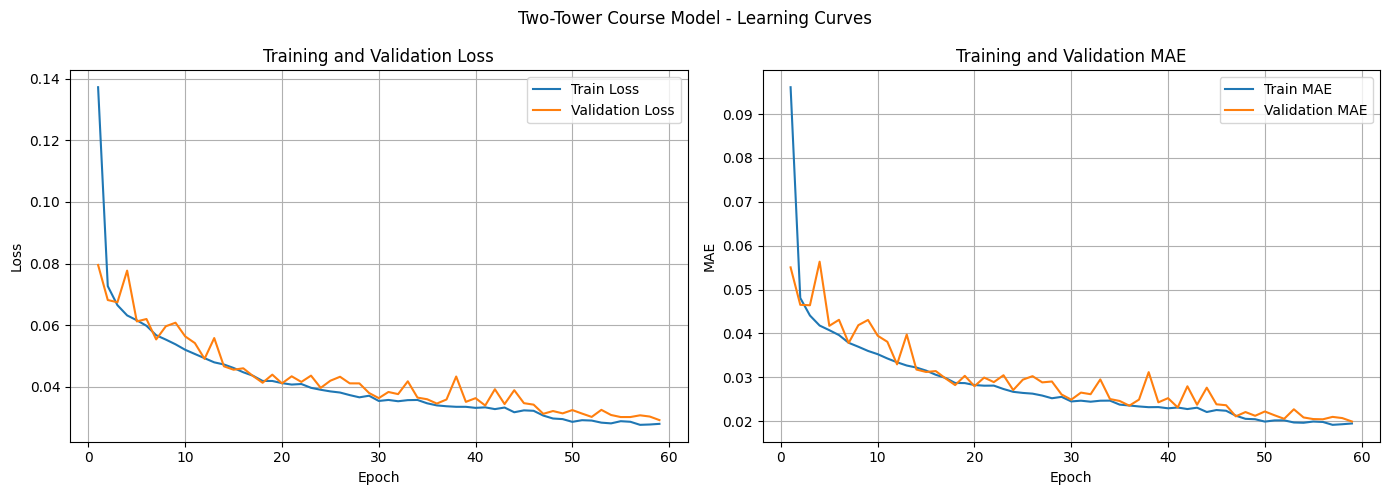

Fig 1: Learning curves (loss & MAE).


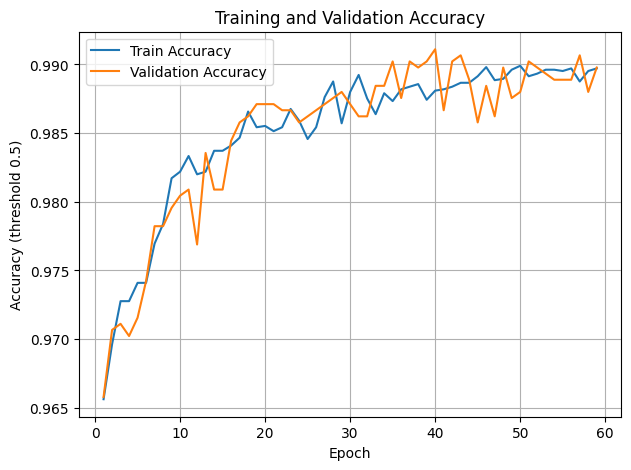

Fig 2: Accuracy curves.


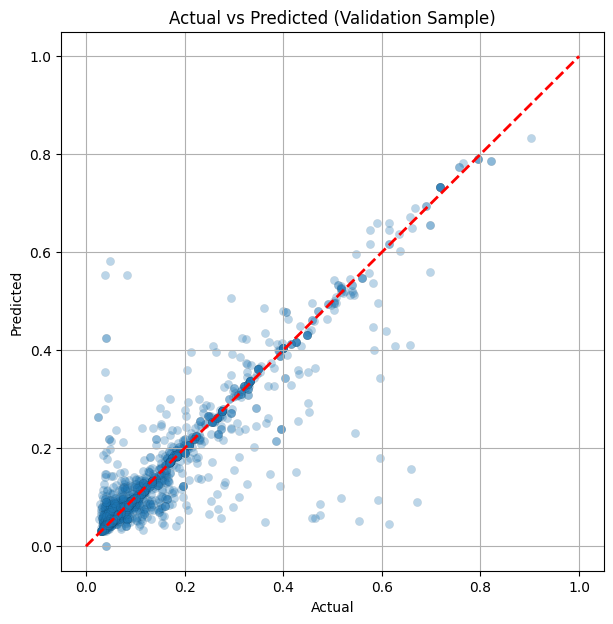

Fig 3: Scatter of actual vs predicted.


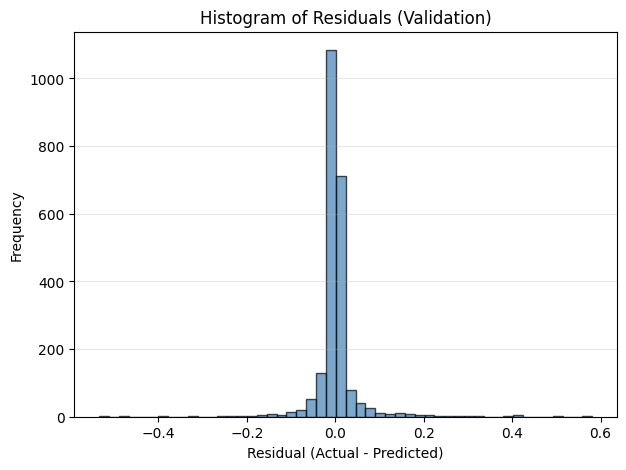

Fig 4: Residual distribution.


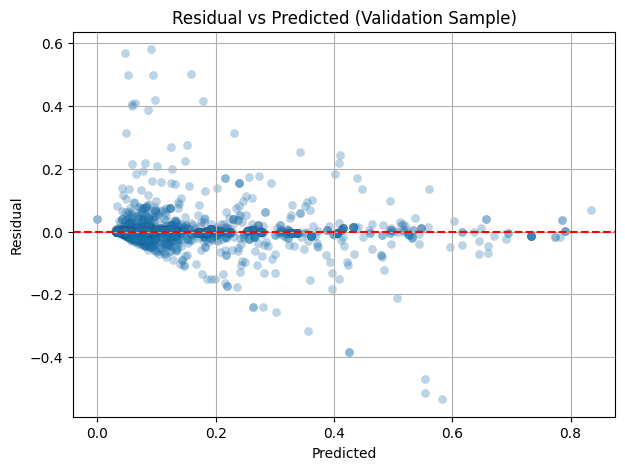

Fig 5: Residual vs predicted.


In [35]:

# ---------- Training Visualizations ----------

epochs_range = range(1, len(history4['loss'])+1)

# 1. Loss and MAE curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, history4['loss'], label='Train Loss')
ax1.plot(epochs_range, history4['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history4['mae'], label='Train MAE')
ax2.plot(epochs_range, history4['val_mae'], label='Validation MAE')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)
plt.suptitle('Two-Tower Course Model - Learning Curves')
plt.tight_layout()
plt.show()
print("Fig 1: Learning curves (loss & MAE).")

# 2. Accuracy curves
plt.figure(figsize=(7,5))
plt.plot(epochs_range, history4['acc'], label='Train Accuracy')
plt.plot(epochs_range, history4['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (threshold 0.5)')
plt.legend()
plt.grid(True)
plt.show()
print("Fig 2: Accuracy curves.")

# 3. Scatter plot actual vs predicted (validation)
val_preds = model4.predict(val_ds4, verbose=0)
y_val_flat = val_targets.flatten()
preds_flat = val_preds.flatten()
indices = np.random.choice(len(y_val_flat), size=min(5000, len(y_val_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_val_flat[indices], preds_flat[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 3: Scatter of actual vs predicted.")

# 4. Histogram of residuals
residuals = y_val_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Validation)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Residual distribution.")

# 5. Residual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[indices], residuals[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 5: Residual vs predicted.")

Test MAE: 0.0199, Test MSE: 0.0028, Test Accuracy (threshold 0.5): 0.9880


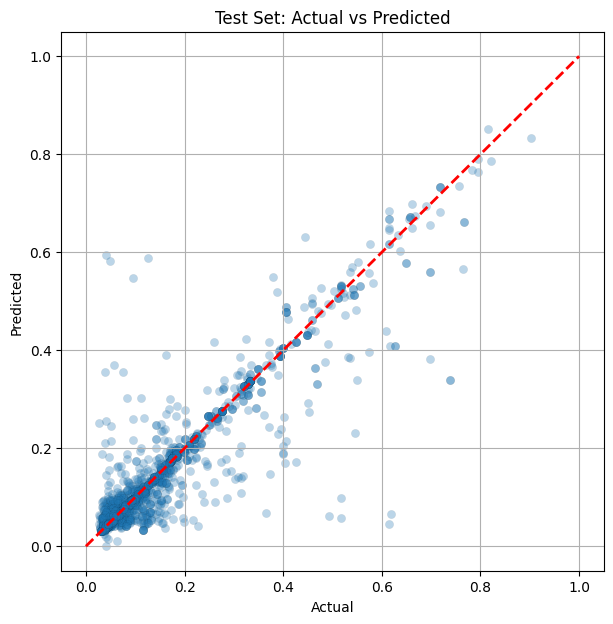

Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.


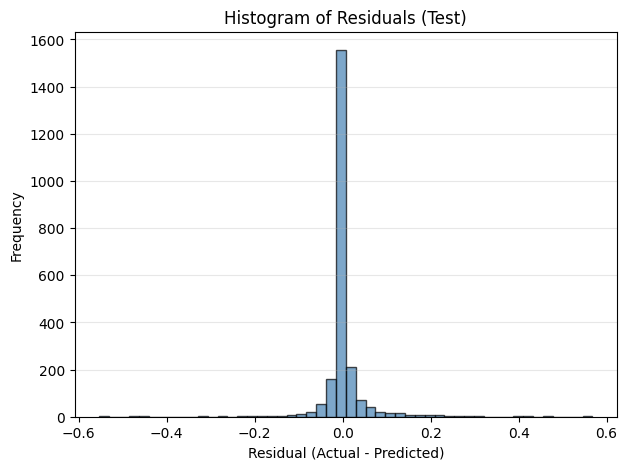

Fig 2: Residual distribution centered near zero shows unbiased predictions.


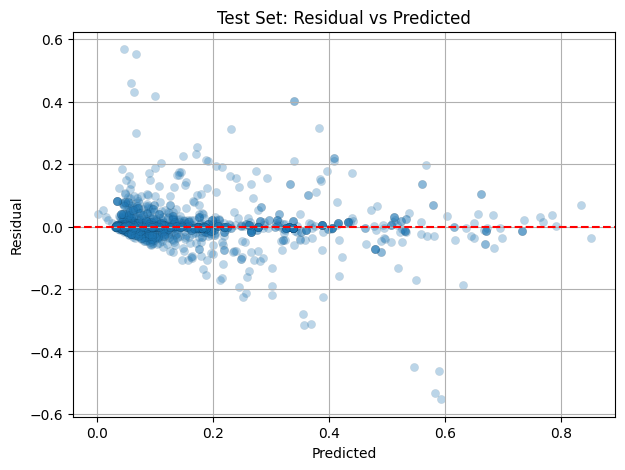

Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.


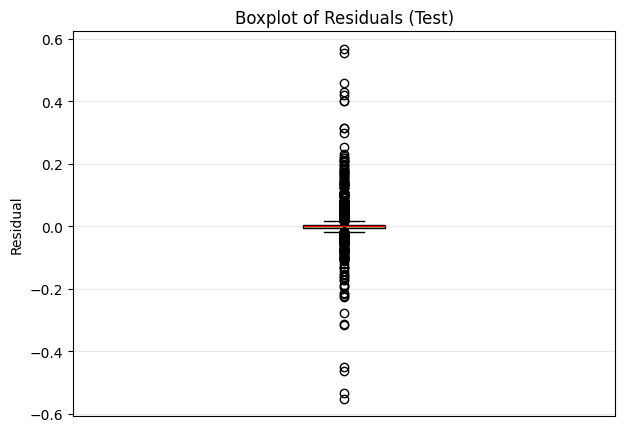

Fig 4: Boxplot shows the spread and symmetry of residuals.


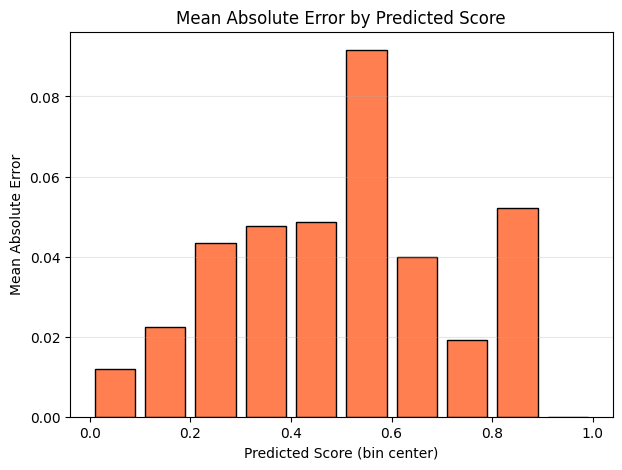

Fig 5: Error distribution across predicted scores. Higher error at extreme bins may indicate poor calibration.


In [36]:
# Evaluate Two-Tower model performance and plot diagnostic charts.


best_model4 = tf.saved_model.load("/kaggle/working/models/two_tower_course_model_savedmodel")
infer_best4 = best_model4.signatures['serving_default']

test_demand = demand_vectors[test_idx_d]
test_course = course_vectors_selected[test_idx_d]   
test_targets = targets[test_idx_d].reshape(-1, 1)

def predict_course_score(model, demand_batch, course_batch, batch_size=256):
    preds = []
    for i in range(0, len(demand_batch), batch_size):
        d = tf.constant(demand_batch[i:i+batch_size], dtype=tf.float16)
        c = tf.constant(course_batch[i:i+batch_size], dtype=tf.float16)
        out = model(args_0=d, args_0_1=c)   
        preds.append(out['output_0'].numpy())
    return np.concatenate(preds, axis=0)

test_preds = predict_course_score(infer_best4, test_demand, test_course)

y_test_flat = test_targets.flatten()
preds_flat = test_preds.flatten()

mae_test = np.mean(np.abs(y_test_flat - preds_flat))
mse_test = np.mean((y_test_flat - preds_flat)**2)
acc_test = np.mean((y_test_flat > 0.5) == (preds_flat > 0.5))
print(f"Test MAE: {mae_test:.4f}, Test MSE: {mse_test:.4f}, Test Accuracy (threshold 0.5): {acc_test:.4f}")

sample_idx = np.random.choice(len(y_test_flat), size=min(5000, len(y_test_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_test_flat[sample_idx], preds_flat[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Set: Actual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.")

residuals = y_test_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Test)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 2: Residual distribution centered near zero shows unbiased predictions.")

plt.figure(figsize=(7,5))
plt.scatter(preds_flat[sample_idx], residuals[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Test Set: Residual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.")

plt.figure(figsize=(7,5))
plt.boxplot(residuals, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'))
plt.title('Boxplot of Residuals (Test)')
plt.ylabel('Residual')
plt.xticks([])
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Boxplot shows the spread and symmetry of residuals.")

bins = np.linspace(0, 1, 11)  
bin_indices = np.digitize(preds_flat, bins)
bin_me = [np.mean(np.abs(residuals[bin_indices == i])) if np.sum(bin_indices == i) > 0 else 0 for i in range(1, len(bins))]
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(7,5))
plt.bar(bin_centers, bin_me, width=0.08, edgecolor='black', color='coral')
plt.xlabel('Predicted Score (bin center)')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error by Predicted Score')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 5: Error distribution across predicted scores. Higher error at extreme bins may indicate poor calibration.")

# 6. Zip Model and Inference Test

In [37]:
zip_model_path = "/kaggle/working/saved_models.zip"
with zipfile.ZipFile(zip_model_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk("/kaggle/working/models"):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, "/kaggle/working/models")
            zf.write(full, arcname)
print(f" Models zipped to {zip_model_path}")

 Models zipped to /kaggle/working/saved_models.zip


In [38]:
# Mass inference for 27 roles with category affinity.

import tensorflow as tf
import numpy as np
import json
from difflib import get_close_matches

cat_data = np.load(os.path.join(PROCESSED_DIR, "cat_embeddings.npz"), allow_pickle=True)
cat_emb_dict = {name: emb for name, emb in zip(cat_data['categories'], cat_data['embeddings'])}

role_data = np.load(os.path.join(PROCESSED_DIR, "role_embeddings.npz"), allow_pickle=True)
role_embeddings = {name: emb for name, emb in zip(role_data['roles'], role_data['embeddings'])}

embed_dim = next(iter(cat_emb_dict.values())).shape[0]
course_categories = df_coursera['Job category'].fillna('Unknown').values
course_cat_embeddings = np.zeros((len(df_coursera), embed_dim), dtype=np.float32)
for i, cat in enumerate(course_categories):
    course_cat_embeddings[i] = cat_emb_dict.get(cat, cat_emb_dict['Unknown'])

course_cat_norms = np.linalg.norm(course_cat_embeddings, axis=1, keepdims=True) + 1e-9

loaded3 = tf.saved_model.load("/kaggle/working/models/skill_priority_scorer_savedmodel")
infer3 = loaded3.signatures['serving_default']
loaded4 = tf.saved_model.load("/kaggle/working/models/two_tower_course_model_savedmodel")
infer4 = loaded4.signatures['serving_default']
print("Both models loaded for mass inference.\n")

def fuzzy_match_skill(skill, vocab_keys, threshold=0.7):
    matches = get_close_matches(skill, vocab_keys, n=1, cutoff=threshold)
    return matches[0] if matches else None

role_user_skills = {
    "Software Engineer": ["react.js", "python", "javascript", "typescript", "next.js", "kubernetes"],
    "Backend Developer": ["python", "go", "docker", "postgresql", "nodejs", "kubernetes"],
    "Frontend Developer": ["react.js", "javascript", "typescript", "css", "next.js", "html"],
    "Full Stack Developer": ["react.js", "javascript", "nodejs", "typescript", "python", "docker"],
    "Mobile Developer": ["kotlin", "git", "swift", "c", "react native"],
    "General IT Specialist": ["python", "next.js", "go", "linux", "r", "kubernetes"],
    "QA Engineer": ["python", "selenium", "next.js", "postman", "javascript"],
    "Security Engineer": ["python", "linux", "kubernetes", "bash", "nmap"],
    "AI Engineer": ["python", "pytorch", "tensorflow", "kubernetes", "docker"],
    "DevOps Engineer": ["kubernetes", "docker", "python", "linux", "bash", "github"],
    "Business Intelligence Analyst": ["python", "tableau", "r", "bigquery", "snowflake"],
    "Data Engineer": ["python", "snowflake", "bigquery", "scala", "nosql", "docker"],
    "Data Scientist": ["python", "r", "tensorflow", "pytorch", "scikit-learn"],
    "Data Analyst": ["python", "tableau", "r", "snowflake", "excel"],
    "Machine Learning Engineer": ["python", "pytorch", "tensorflow", "mlflow", "kubernetes"],
    "Solutions Architect": ["python", "kubernetes", "docker", "nodejs", "react.js"],
    "Site Reliability Engineer": ["python", "kubernetes", "linux", "docker", "bash", "go"],
    "Cloud Engineer": ["kubernetes", "python", "linux", "docker", "bash"],
    "Product Manager": ["go", "next.js", "python", "tableau"],
    "IT Consultant": ["python", "go", "javascript", "c#", "docker"],
    "Network Engineer": ["python", "linux", "vmware", "wireshark", "bash"],
    "Embedded/IoT Engineer": ["c", "c++", "python", "linux", "git"],
    "Database Administrator": ["postgresql", "linux", "mysql", "python", "mongodb"],
    "Cyber Security Analyst": ["python", "linux", "bash", "nmap", "metasploit"],
    "Business Analyst": ["python", "tableau", "go", "snowflake", "excel"],
    "Robotics Engineer": ["python", "javascript", "selenium", "git", "docker"],
    "ERP Consultant": ["next.js", "c", "go", "python", "microsoft dynamics"]
}

CAT_WEIGHT = 0.4

for role, raw_skills in role_user_skills.items():
    print(f"{'='*60}")
    print(f"Role: {role}")
    print(f"User skills (raw): {raw_skills}")

    cv_skills = [s.lower().strip() for s in raw_skills if s.strip()]
    user_vec_li = np.zeros((1, N_SKILLS_LI), dtype=np.float32)
    vocab_li_keys = list(skill_to_idx_li.keys())
    recognized = []
    for s in cv_skills:
        if s in skill_to_idx_li:
            user_vec_li[0, skill_to_idx_li[s]] = 1.0
            recognized.append(s)
        else:
            best = fuzzy_match_skill(s, vocab_li_keys, threshold=0.7)
            if best:
                user_vec_li[0, skill_to_idx_li[best]] = 1.0
                recognized.append(best)
    print(f"Recognized skills: {recognized}")

    role_idx = np.array([[role_to_idx[role]]], dtype=np.int32)
    out3 = infer3(user_skills=tf.constant(user_vec_li), role_index=tf.constant(role_idx))
    pred_scores = out3['output_0'].numpy()[0]

    mask = user_vec_li[0] == 0
    pred_scores_masked = np.where(mask, pred_scores, -1.0)
    top_indices = np.argsort(pred_scores_masked)[::-1][:15]

    missing_skills = []
    for idx in top_indices:
        score = pred_scores_masked[idx]
        if score > 0:
            skill_name = idx_to_skill_li[str(idx)]
            missing_skills.append((skill_name, score))

    print("Top 15 missing skills:")
    for i, (skill, score) in enumerate(missing_skills, 1):
        print(f"  {i:2d}. {skill:<30s} {score:.4f}")

    demand_vec_li = np.zeros(N_SKILLS_LI, dtype=np.float32)
    for skill, _ in missing_skills:
        if skill in skill_to_idx_li:
            demand_vec_li[skill_to_idx_li[skill]] = 1.0

    demand_batch = np.tile(demand_vec_li.reshape(1, -1), (num_courses, 1)).astype(np.float32)
    course_batch = course_vectors_all.astype(np.float32)

    demand_f16 = tf.cast(tf.constant(demand_batch), tf.float16)
    course_f16 = tf.cast(tf.constant(course_batch), tf.float16)

    out4 = infer4(args_0=demand_f16, args_0_1=course_f16)
    match_scores = list(out4.values())[0].numpy().flatten()

    role_emb = role_embeddings[role]
    role_norm = np.linalg.norm(role_emb) + 1e-9
    cat_affinities = np.dot(course_cat_embeddings, role_emb) / (course_cat_norms.flatten() * role_norm)
    cat_affinities = np.clip(cat_affinities, 0.0, 1.0)

    final_scores = (1 - CAT_WEIGHT) * match_scores + CAT_WEIGHT * cat_affinities

    seen_urls = set()
    deduped_indices = []
    for cid in np.argsort(final_scores)[::-1]:
        url = df_coursera.iloc[cid]['Url']
        if url not in seen_urls:
            seen_urls.add(url)
            deduped_indices.append(cid)
        if len(deduped_indices) == 20:
            break
    top_course_idx = deduped_indices[:10]

    demand_vec_cr = np.zeros(N_SKILLS_CR, dtype=np.float32)
    for skill, _ in missing_skills:
        if skill in linkedin_to_coursera:
            for cr_skill in linkedin_to_coursera[skill]:
                if cr_skill in skill_to_idx_cr:
                    demand_vec_cr[skill_to_idx_cr[cr_skill]] = 1.0

    print("\nTop-10 Recommended Courses:")
    for i, cid in enumerate(top_course_idx, 1):
        score = final_scores[cid]
        row = df_coursera.iloc[cid]
        name = row['Name']
        url = row['Url']
        job_category = row.get('Job category', '')
        difficulty = row.get('Difficulty', '')
        duration = row.get('Duration', '')

        all_skills = [idx_to_skill_cr[str(k)] for k in range(N_SKILLS_CR) if course_vectors_all[cid][k] > 0]
        covered = [idx_to_skill_cr[str(k)] for k in range(N_SKILLS_CR) if course_vectors_all[cid][k] > 0 and demand_vec_cr[k] > 0]

        print(f"  {i:2d}. {name:<60s} score: {score:.4f}")
        print(f"       {url}")
        print(f"       Job Category : {job_category}")
        print(f"       Difficulty   : {difficulty}")
        print(f"       Duration     : {duration}")
        print(f"       All Skills   : {all_skills[:10]}{'...' if len(all_skills)>10 else ''}")
        print(f"       Covered      : {covered}")
    print("\n")

print("Mass inference completed.")

Both models loaded for mass inference.

Role: Software Engineer
User skills (raw): ['react.js', 'python', 'javascript', 'typescript', 'next.js', 'kubernetes']
Recognized skills: ['react.js', 'python', 'javascript', 'typescript', 'next.js', 'kubernetes']
Top 15 missing skills:
   1. vue                            0.8569
   2. css                            0.8357
   3. kotlin                         0.8116
   4. spring boot                    0.7787
   5. graphql                        0.6975
   6. react native                   0.6959
   7. webpack                        0.6529
   8. nosql                          0.6363
   9. microservices architecture     0.6118
  10. .net                           0.6091
  11. jquery                         0.5911
  12. jest                           0.5869
  13. component libraries            0.5857
  14. django                         0.5837
  15. redis                          0.5784

Top-10 Recommended Courses:
   1. Modern Web Development with 

In [39]:
print("TensorBoard logs:")
print(f"  Skill Priority Scorer: {log_dir}")
print(f"  Two-Tower Course    : {log_dir4}")
print("Launch in notebook with: %tensorboard --logdir /kaggle/working/logs")

TensorBoard logs:
  Skill Priority Scorer: /kaggle/working/logs/skill_priority_scorer/20260604-064804
  Two-Tower Course    : /kaggle/working/logs/two_tower_course/20260604-064857
Launch in notebook with: %tensorboard --logdir /kaggle/working/logs


# *7. ZIP ALL*

In [40]:
import json
import datetime

# Buat file penanda untuk Skill Priority Scorer
marker3 = {
    "model_name": "Skill Priority Scorer (TF-IDF)",
    "trained_at": datetime.datetime.now().isoformat(),
    "vocab_size": N_SKILLS_LI,
    "target_type": "TF-IDF"
}
with open("/kaggle/working/models/skill_priority_scorer_savedmodel/model_info.json", "w") as f:
    json.dump(marker3, f, indent=2)
print(" Penanda model Skill Priority Scorer disimpan.")

# Buat file penanda untuk Two-Tower Course Model
marker4 = {
    "model_name": "Two-Tower Course (SBERT mapping + Category Affinity)",
    "trained_at": datetime.datetime.now().isoformat(),
    "demand_type": "TF-IDF top-15",
    "mapping_type": "SBERT semantic"
}
with open("/kaggle/working/models/two_tower_course_model_savedmodel/model_info.json", "w") as f:
    json.dump(marker4, f, indent=2)
print(" Penanda model Two-Tower Course disimpan.")

 Penanda model Skill Priority Scorer disimpan.
 Penanda model Two-Tower Course disimpan.


In [46]:

import shutil
import os
import zipfile
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
final_zip = f"/kaggle/working/qlop_full_export_{timestamp}.zip"

with zipfile.ZipFile(final_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    # 1. Skill Priority Scorer model
    model3_dir = "/kaggle/working/models/skill_priority_scorer_savedmodel"
    if os.path.exists(model3_dir):
        for root, dirs, files in os.walk(model3_dir):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, "/kaggle/working/models")
                zf.write(full_path, arcname)
        print("Skill Priority Scorer model added")

    # 2. Two‑Tower Course model
    model4_dir = "/kaggle/working/models/two_tower_course_model_savedmodel"
    if os.path.exists(model4_dir):
        for root, dirs, files in os.walk(model4_dir):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, "/kaggle/working/models")
                zf.write(full_path, arcname)
        print("Two‑Tower Course model added")

    # 3. TensorBoard logs
    logs_dir = "/kaggle/working/logs"
    if os.path.exists(logs_dir):
        for root, dirs, files in os.walk(logs_dir):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, "/kaggle/working/logs")
                zf.write(full_path, arcname)
        print("TensorBoard logs added")

    # 4. Processed data (vocab, embeddings, dll.)
    processed_dir = "/kaggle/working/processed"
    if os.path.exists(processed_dir):
        for root, dirs, files in os.walk(processed_dir):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, "/kaggle/working/processed")
                zf.write(full_path, arcname)
        print("processed data added")

print(f"\n All components saved to:\n   {final_zip}")
print("   Download this single file from the Output panel.")

Skill Priority Scorer model added
Two‑Tower Course model added
TensorBoard logs added
processed data added

 All components saved to:
   /kaggle/working/qlop_full_export_20260604_070007.zip
   Download this single file from the Output panel.
